# 2026-03-10 AMOC timeseries
Stephanie Leroux

Demo how to read and use the shared AMOC files to reproduce Fig.6b from Leroux et al 2018:

REF: Stephanie Leroux, Thierry Penduff, Laurent Bessières, Jean-Marc Molines, Jean-Michel Brankart, et
al.. Intrinsic and Atmospherically Forced Variability of the AMOC: Insights from a Large-Ensemble
Ocean Hindcast. Journal of Climate, American Meteorological Society, 2018, 31 (3), pp.1183-1203.
10.1175/JCLI-D-17-0168.1

## Packages and functions

In [6]:
import os
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
################################################
# FUNCTION DEFS
################################################    



def make_ensemble_from_clim(ds, skip_years, seg_len=19, var='amoc'):
    """
    Convert a single long time series into an ensemble of segments.
    
    Parameters:
    -----------
    ds        : xarray Dataset with time_counter dimension
    skip_years: number of years to discard at the beginning
    seg_len   : length of each segment in years (default 19)
    var       : variable name to reshape (default 'amoc')
    
    Returns:
    --------
    ds_reshaped: xarray Dataset with new ensmb dimension
    """
    # Remove first skip_years
    ds_trimmed = ds.isel(time_counter=slice(skip_years, None))
    
    # How many full segments fit?
    n_segments = len(ds_trimmed.time_counter) // seg_len
    remainder  = len(ds_trimmed.time_counter) % seg_len
    print(f"{n_segments} full segments of {seg_len} years, {remainder} years discarded")
    
    # Trim to exact multiple
    ds_trimmed = ds_trimmed.isel(time_counter=slice(0, n_segments * seg_len))
    
    # Reshape into (ensmb, time_counter, y) - no x anymore
    data      = ds_trimmed[var].values  # (time_counter, y)
    new_shape = (n_segments, seg_len) + data.shape[1:]  # (ensmb, time_counter, y)
    var_reshaped = xr.Variable(('ensmb', 'time_counter', 'y'), data.reshape(new_shape))
    
    ds_reshaped = xr.Dataset(
        {var: var_reshaped},
        coords={
            'ensmb':        np.arange(n_segments),
            'time_counter': np.arange(seg_len),
            'nav_lat':      ds_trimmed['nav_lat'],
        }
    )
    return ds_reshaped


def detrend_ensemble(ds_reshaped, var='amoc', degree=2):
    """
    Detrend along time_counter for each (ensmb, y, x) point.
    Works regardless of dimension order.
    """
    def _detrend_1d(ts):
        t = np.arange(len(ts))
        coeffs = np.polyfit(t, ts, degree)
        fit = np.polyval(coeffs, t)
        return ts - fit

    da_detrended = xr.apply_ufunc(
        _detrend_1d,
        ds_reshaped[var],
        input_core_dims=[['time_counter']],
        output_core_dims=[['time_counter']],
        vectorize=True,
    )

    return ds_reshaped.assign({var: da_detrended})
    

def Fsaveplt(fig,diro,namo,dpifig=300):
    """Save plot to file.
    
    Parameters:
    - fig: Figure properties to save.
    - diro (str): Output directory.
    - namo (str): Name of the output plot.
    - dpifig (int): Resolution (dpi) of saved plot.
    
    Returns:
    None
   """
    
    fig.savefig(diro+namo+".png", facecolor=fig.get_facecolor(),
                edgecolor='none',dpi=dpifig,bbox_inches='tight', pad_inches=0.01)
    print(diro+namo+".png")
    plt.close(fig) 
    
       

# for jupyter notebook display
%matplotlib inline


diri="/lustre/fsstor/projects/rech/wbh/regi915/DATA-AMOC/MOCZ/"

# READ  and detrend the OCCITENS ensemble

In [2]:
# read data
ds= xr.open_dataset(diri + "moc.ORCA025.L75-OCCITENS.1960-2015.1a.ATL_max_sh.nc")

# trim to dates
ds = ds.sel(time_counter=slice("1994-01-01", "2012-12-31"))

#detrend along time for each member (second order polynomial fit)
ds_dt = detrend_ensemble(ds, degree=2)

### quick check of the detrending on a timeseries at choosen latitude:

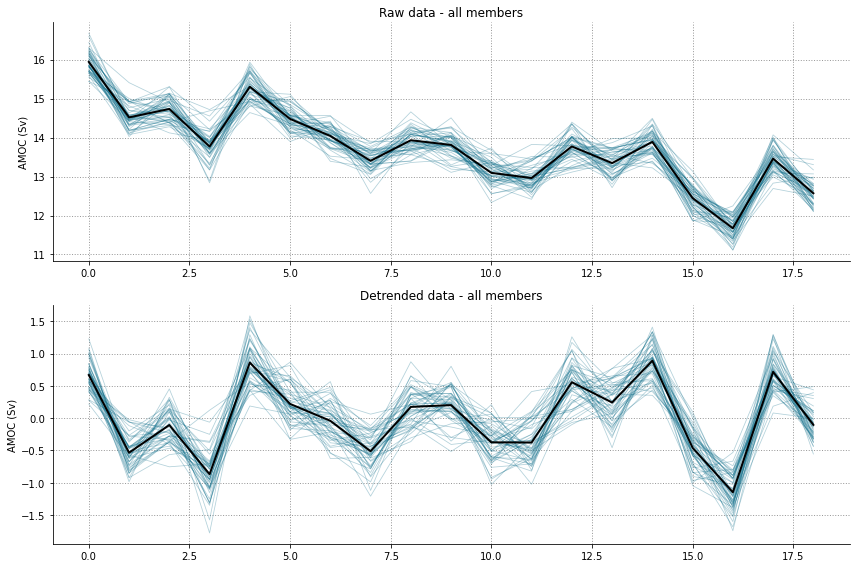

/lustre/fsstor/projects/rech/wbh/regi915/DATA-AMOC/MOCZ/TScheckdetrending_lat_26N.png


In [3]:

#choose latitude to look at:
latselect = 26.0

lat = ds['nav_lat'].values  # (673,)
iylat = np.argmin(np.abs(lat - latselect))
latnear = int(round(lat[iylat]))


fig, axes = plt.subplots(2, 1, figsize=(12, 8), facecolor='white')

# Raw data - all 50 members
ax = axes[0]
for ie in range(ds.dims['ensmb']):
    ax.plot(ds['amoc'].isel(ensmb=ie, y=iylat).values, 
            color="#086A87", alpha=0.3, linewidth=0.8)
ax.plot(ds['amoc'].isel(y=iylat).mean(dim='ensmb'), color='k', linewidth=2)
ax.set_title('Raw data - all members')
ax.set_ylabel('AMOC (Sv)')
ax.yaxis.grid(color="grey", linestyle=":", linewidth=1, alpha=0.8)
ax.xaxis.grid(color="grey", linestyle=":", linewidth=1, alpha=0.8)
ax.set_axisbelow(True)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Detrended data - all 50 members
ax = axes[1]
for ie in range(ds.dims['ensmb']):
    ax.plot(ds_dt['amoc'].isel(ensmb=ie, y=iylat).values, 
            color="#086A87", alpha=0.3, linewidth=0.8)
ax.plot(ds_dt['amoc'].isel(y=iylat).mean(dim='ensmb'), color='k', linewidth=2)
ax.set_title('Detrended data - all members')
ax.set_ylabel('AMOC (Sv)')
ax.yaxis.grid(color="grey", linestyle=":", linewidth=1, alpha=0.8)
ax.xaxis.grid(color="grey", linestyle=":", linewidth=1, alpha=0.8)
ax.set_axisbelow(True)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

plt.tight_layout()
plt.show()

# use in plot name
Fsaveplt(fig, diri, f'TScheckdetrending_lat_{latnear}N', dpifig=300)

# READ and detrend the two climatologies (300-ish years)
Discard the first 25 years and chunck the rest in 16 segments of 19 years (pseudo-ensemble members) then detrend each of the 16 pseudo memebrs.

### CLIM-OCCITENS:

In [7]:
ds2 = xr.open_dataset(diri + "moc.ORCA025.L75-MOCCITCLIM.0001-0330.1a.ATL_max_sh.nc")
ds2_reshaped = make_ensemble_from_clim(ds2, skip_years=25, seg_len=19)
ds2_dt       = detrend_ensemble(ds2_reshaped, degree=2)

16 full segments of 19 years, 0 years discarded


### CLIM-Gregorio

In [8]:
ds3 = xr.open_dataset(diri + "moc.ORCA025-MJM01.0001-0327.1a.ATL_max_sh.nc")
ds3_reshaped = make_ensemble_from_clim(ds3, skip_years=23, seg_len=19)
ds3_dt       = detrend_ensemble(ds3_reshaped, degree=2)

16 full segments of 19 years, 0 years discarded


# Lat-variance plot as in Fig.6b of Leroux et al 2018

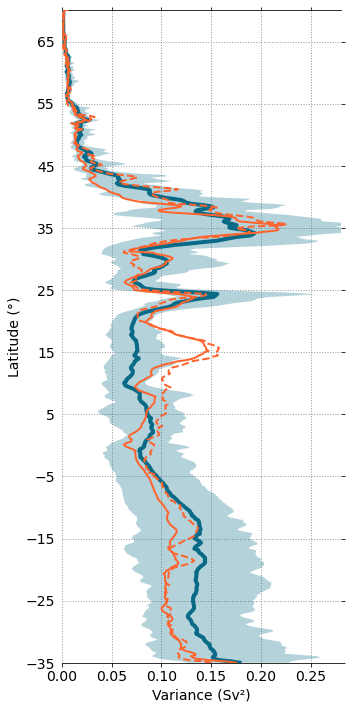

/lustre/fsstor/projects/rech/wbh/regi915/DATA-AMOC/MOCZ/checkAMOC_asFIG6b.png


In [9]:
# get latitudes
lat = ds2['nav_lat'].values  

# OCCITENS AMOC ensemble variance then averaged with time 
occitens_var = ds_dt['amoc'].var(dim='ensmb', ddof=0).mean(dim='time_counter').values  
# also compute min-max enveloppe of ensemble variance along time
occitens_min = ds_dt['amoc'].var(dim='ensmb', ddof=0).min(dim='time_counter').values
occitens_max = ds_dt['amoc'].var(dim='ensmb', ddof=0).max(dim='time_counter').values

# CLIM-OCCITENS pseudo-ensemble variance then averaged with time
occiclim_var = ds2_dt['amoc'].var(dim='ensmb',ddof=0).mean(dim='time_counter').squeeze()

# CLIM-gregorio pseudo-ensemble variance then averaged with time
mjm_var = ds3_dt['amoc'].var(dim='ensmb',ddof=0).mean(dim='time_counter').squeeze()


#### PLOT
fig1 = plt.figure(figsize=([5,12]),facecolor='white')  #A9D0F5

# plot the 3 lines
plt.plot(occitens_var,lat,color="#086A87",linewidth=4,linestyle="-",label='OCCI', zorder=3)
plt.plot(occiclim_var.values,lat,color="#fe642e",linewidth=2,linestyle="-",label='CLIM-OCCI', zorder=3)
plt.plot(mjm_var.values,lat,color="#fe642e",linewidth=2,linestyle="--",label="CLIM-Gregorio", zorder=3)

# plot shaded envelop
plt.fill(
    np.append(occitens_max, occitens_min[::-1]),
    np.append(lat, lat[::-1]),
    color="#086A87", alpha=0.3, linewidth=0.1, zorder=2)

# Fine tune the appearance of the plot
plt.ylim( -35, 70 )
plt.xlim( 0, 0.28 )

ax = plt.gca()
# Spines
ax.spines["top"].set_visible(True)
ax.spines["bottom"].set_visible(True)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Grid
ax.yaxis.grid(color="grey", linestyle=":", linewidth=1, alpha=0.8)
ax.xaxis.grid(color="grey", linestyle=":", linewidth=1, alpha=0.8)
ax.set_axisbelow(True)  # grid behind the lines

# Ticks - single consistent instruction
ax.tick_params(axis="both", which="both", 
               bottom=True, top=True, left=False, right=True,
               labelbottom=True, labeltop=False,
               labelleft=True, labelright=False,
               direction='out', labelsize=14)

# Labels
ax.set_yticks(np.arange(-35, 70, 10))
ax.yaxis.label.set_size(14)
ax.xaxis.label.set_size(14)
ax.yaxis.set_label_position("left")
plt.ylabel(u"Latitude (°)")
plt.xlabel('Variance (Sv²)')

plt.show()

# save plot
Fsaveplt(fig1,diri,'checkAMOC_asFIG6b',dpifig=300)

# Same as FIG6b but also adding the regional ensemble variances:

* TCLB300:

In [10]:
# read data
ds4= xr.open_dataset(diri + "moc.NATL025-TCLB300.1994-2012.1a_max_sh.nc")

# trim to dates
ds4 = ds4.sel(time_counter=slice("1994-01-01", "2012-12-31"))

#detrend along time for each member (second order polynomial fit)
ds4_dt = detrend_ensemble(ds4, degree=2)

* GSL301

In [11]:
# read data
ds5= xr.open_dataset(diri + "moc.NATL025-GSL301.1993-2012.1a_max_sh.nc")

# trim to dates
ds5 = ds5.sel(time_counter=slice("1994-01-01", "2012-12-31"))

#detrend along time for each member (second order polynomial fit)
ds5_dt = detrend_ensemble(ds5, degree=2)

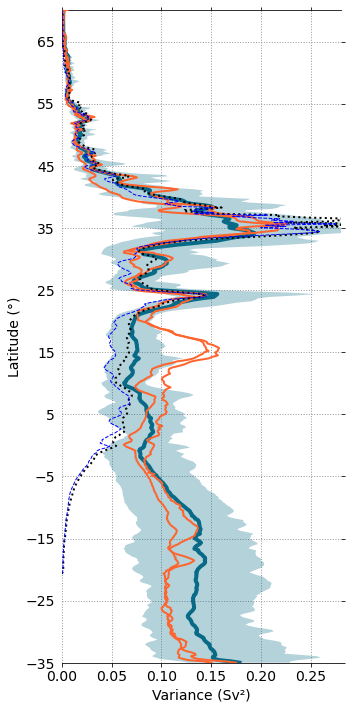

/lustre/fsstor/projects/rech/wbh/regi915/DATA-AMOC/MOCZ/checkAMOC_asFIG6b_withreg.png


In [12]:
# get latitudes
lat = ds2['nav_lat'].values 
latreg = ds4['nav_lat'].values 

# OCCITENS AMOC ensemble variance then averaged with time 
occitens_var = ds_dt['amoc'].var(dim='ensmb', ddof=0).mean(dim='time_counter').values  
# also compute min-max enveloppe of ensemble variance along time
occitens_min = ds_dt['amoc'].var(dim='ensmb', ddof=0).min(dim='time_counter').values
occitens_max = ds_dt['amoc'].var(dim='ensmb', ddof=0).max(dim='time_counter').values

# TCLB
tclb_var = ds4_dt['amoc'].var(dim='ensmb', ddof=0).mean(dim='time_counter').values  

# GSL
gsl_var = ds5_dt['amoc'].var(dim='ensmb', ddof=0).mean(dim='time_counter').values  

# CLIM-OCCITENS pseudo-ensemble variance then averaged with time
occiclim_var = ds2_dt['amoc'].var(dim='ensmb',ddof=0).mean(dim='time_counter').squeeze().values

# CLIM-gregorio pseudo-ensemble variance then averaged with time
mjm_var = ds3_dt['amoc'].var(dim='ensmb',ddof=0).mean(dim='time_counter').squeeze().values


#### PLOT
fig1 = plt.figure(figsize=([5,12]),facecolor='white')  #A9D0F5

# plot the 3 lines
plt.plot(occitens_var,lat,color="#086A87",linewidth=4,linestyle="-",label='ENS-OCCI', zorder=3)
plt.plot(occiclim_var,lat,color="#fe642e",linewidth=2,linestyle="-",label='CLIM-OCCI', zorder=3)
plt.plot(mjm_var,lat,color="#fe642e",linewidth=2,linestyle="-",label='CLIM-Gregorio', zorder=3)
plt.plot(gsl_var,latreg,color="k",linewidth=2,linestyle=":",label="ENS-GSL", zorder=3)
plt.plot(tclb_var,latreg,color="b",linewidth=1,linestyle="--",label="ENS-TCLB", zorder=3)


# plot shaded envelop
plt.fill(
    np.append(occitens_max, occitens_min[::-1]),
    np.append(lat, lat[::-1]),
    color="#086A87", alpha=0.3, linewidth=0.1, zorder=2)

# Fine tune the appearance of the plot
plt.ylim( -35, 70 )
plt.xlim( 0, 0.28 )

ax = plt.gca()
# Spines
ax.spines["top"].set_visible(True)
ax.spines["bottom"].set_visible(True)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Grid
ax.yaxis.grid(color="grey", linestyle=":", linewidth=1, alpha=0.8)
ax.xaxis.grid(color="grey", linestyle=":", linewidth=1, alpha=0.8)
ax.set_axisbelow(True)  # grid behind the lines

# Ticks - single consistent instruction
ax.tick_params(axis="both", which="both", 
               bottom=True, top=True, left=False, right=True,
               labelbottom=True, labeltop=False,
               labelleft=True, labelright=False,
               direction='out', labelsize=14)

# Labels
ax.set_yticks(np.arange(-35, 70, 10))
ax.yaxis.label.set_size(14)
ax.xaxis.label.set_size(14)
ax.yaxis.set_label_position("left")
plt.ylabel(u"Latitude (°)")
plt.xlabel('Variance (Sv²)')

plt.show()

# save plot
Fsaveplt(fig1,diri,'checkAMOC_asFIG6b_withreg',dpifig=300)